<a href="https://colab.research.google.com/github/Lstemm/LRS.DSC-502.Project/blob/main/DSC_502_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# Load libraries and CSV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv

with open(r"/content/drive/MyDrive/League_of_Legends_Data - Sheet1 (2).csv") as f:
    reader = csv.DictReader(f)
    League_of_Legends_Data = list(reader)

In [2]:
# Create Data Frame
df = pd.DataFrame(League_of_Legends_Data)
df.head(10)

,match_id,game_duration,patch_version,queue_type,team,role,champion,win_loss,kills,deaths,assists,cs,cs_per_min,gold_earned,damage,vision_score,first_blood,game_review
0,5486945849,0:24:40,26.3,ranked,blue,top,Dr.Mundo,win,15,5,8,203,8.2,14609,28831,8,no,Late Bloomer
1,5486945849,0:24:40,26.3,ranked,blue,jungle,Diana,win,12,2,11,151,6.1,12186,22058,27,no,Unstoppable
2,5486945849,0:24:40,26.3,ranked,blue,mid,Vex,win,5,2,10,133,5.4,8460,18730,20,no,Late Bloomer
3,5486945849,0:24:40,26.3,ranked,blue,adc,Jinx,win,10,1,7,228,9.2,13573,29852,12,no,Unstoppable
4,5486945849,0:24:40,26.3,ranked,blue,support,Nami,win,0,2,25,14,0.6,7945,6698,29,no,Unstoppable
5,5486945849,0:24:40,26.3,ranked,red,top,Vayne,loss,4,10,3,146,5.9,9493,29556,13,no,Downfall
6,5486945849,0:24:40,26.3,ranked,red,jungle,Master Yi,loss,6,6,2,121,4.9,9871,18312,29,yes,Downfall
7,5486945849,0:24:40,26.3,ranked,red,mid,Galio,loss,2,6,4,160,6.5,8590,19269,10,no,Struggle
8,5486945849,0:24:40,26.3,ranked,red,adc,Kai'Sa,loss,0,9,1,181,7.3,8834,10328,12,no,Struggle
9,5486945849,0:24:40,26.3,ranked,red,support,Nautilus,loss,0,11,5,32,1.3,6272,8556,57,no,Struggle


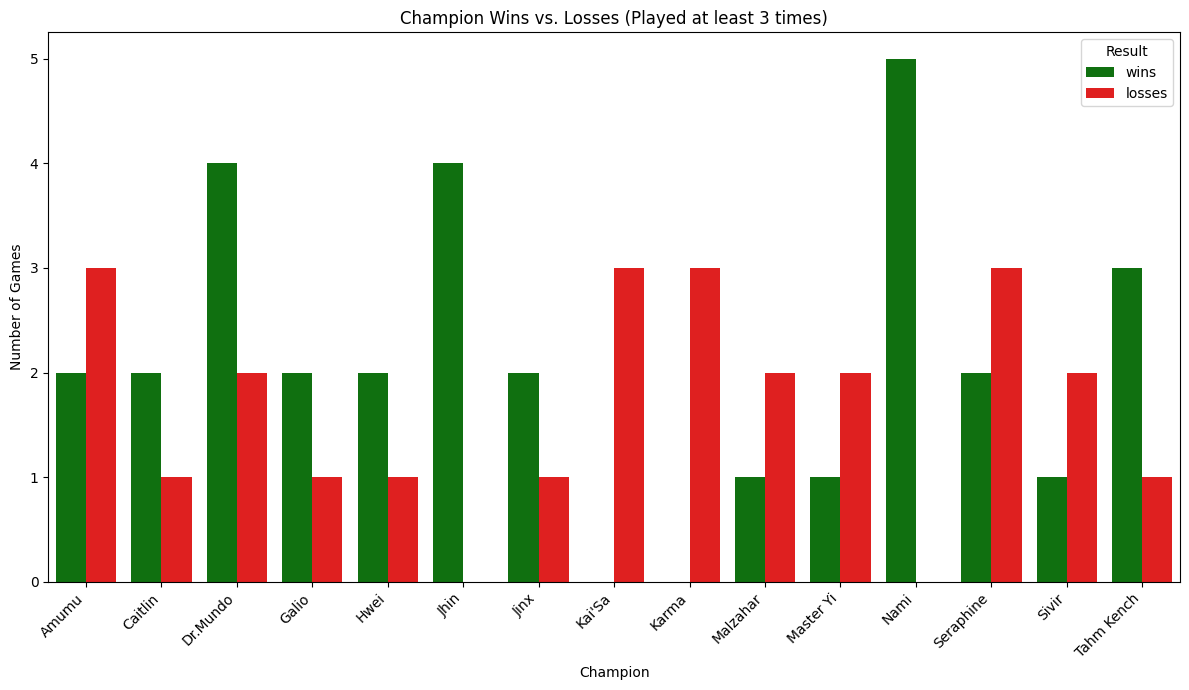

In [3]:
winners = df[(df['win_loss'] == 'win')]
champ_win_counts = winners['champion'].value_counts().reset_index()
champ_win_counts.columns = ['champion', 'wins']

losers = df[(df['win_loss'] == 'loss')]
champ_loss_counts = losers['champion'].value_counts().reset_index()
champ_loss_counts.columns = ['champion', 'losses']

combined_counts = pd.merge(champ_win_counts, champ_loss_counts, on='champion', how='outer').fillna(0)
combined_counts['total_plays'] = combined_counts['wins'] + combined_counts['losses']

filtered_champions = combined_counts[combined_counts['total_plays'] >= 3]

melted_df = filtered_champions.melt(id_vars=['champion', 'total_plays'], value_vars=['wins', 'losses'], var_name='result', value_name='count')

plt.figure(figsize=(12, 7))
sns.barplot(x='champion', y='count', hue='result', data=melted_df, palette={'wins': 'green', 'losses': 'red'})
plt.title('Champion Wins vs. Losses (Played at least 3 times)')
plt.xlabel('Champion')
plt.ylabel('Number of Games')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Result')
plt.tight_layout()
plt.show()

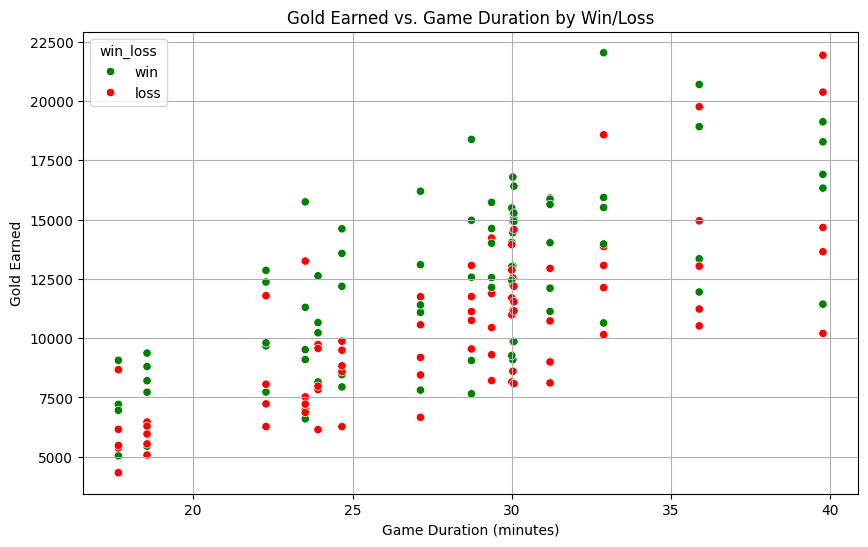

In [ ]:
# Scatter Plot


df['gold_earned'] = pd.to_numeric(df['gold_earned'], errors='coerce')


def convert_duration_to_minutes(duration_str):
    parts = str(duration_str).split(':')
    if len(parts) == 3:
        h, m, s = map(int, parts)
    elif len(parts) == 2:
        h = 0
        m, s = map(int, parts)
    else:
        return 0
    return h * 60 + m + s / 60

df['game_duration_minutes'] = df['game_duration'].apply(convert_duration_to_minutes)


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='game_duration_minutes',
    y='gold_earned',
    hue='win_loss',
    palette={'win': 'green', 'loss': 'red'}
)
plt.xlabel('Game Duration (minutes)')
plt.ylabel('Gold Earned')
plt.title('Gold Earned vs. Game Duration by Win/Loss')
plt.grid(True)
plt.show()

<Axes: title={'center': 'Total Wins from Each Team'}, ylabel='count'>

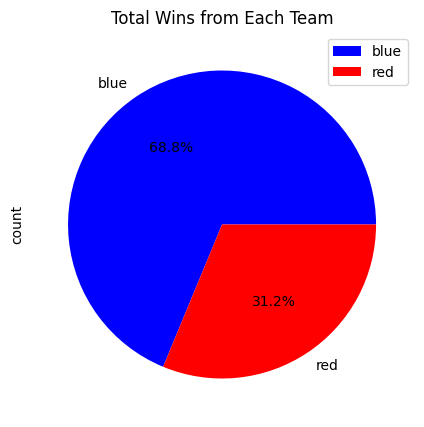

In [ ]:
# Pie Chart

winners = df[(df['win_loss'] == 'win')]
team_win_counts = winners['team'].value_counts()
colors = ['blue', 'red']

team_win_counts.plot.pie(autopct='%1.1f%%', legend=True, figsize=(6,5), title='Total Wins from Each Team', colors=colors)

The Blue Team Has won far more times then the Red Team, suggesting that one would have better chances of winning if they started on the Blue Team.

In [ ]:
# Line Charts

df['gold_earned'] = pd.to_numeric(df['gold_earned'], errors='coerce')

def convert_duration_to_minutes(duration_str):
    parts = str(duration_str).split(':')
    if len(parts) == 3:
        h, m, s = map(int, parts)
    elif len(parts) == 2:
        h = 0
        m, s = map(int, parts)
    else:
        return 0
    return h * 60 + m + s / 60

df['game_duration_minutes'] = df['game_duration'].apply(convert_duration_to_minutes)


In [ ]:
duration_bins = [0, 20, 25, 30, 35, float('inf')]
duration_labels = ['0-20', '20-25', '25-30', '30-35', '35+']

df['duration_bucket'] = pd.cut(df['game_duration_minutes'], bins=duration_bins, labels=duration_labels, right=False)

blue_wins = df[(df['team'] == 'blue') & (df['win_loss'] == 'win')].groupby('duration_bucket').size().reindex(duration_labels, fill_value=0)
blue_total_games = df[df['team'] == 'blue'].groupby('duration_bucket').size().reindex(duration_labels, fill_value=0)
blue_win_rate = (blue_wins / blue_total_games * 100).fillna(0)

red_wins = df[(df['team'] == 'red') & (df['win_loss'] == 'win')].groupby('duration_bucket').size().reindex(duration_labels, fill_value=0)
red_total_games = df[df['team'] == 'red'].groupby('duration_bucket').size().reindex(duration_labels, fill_value=0)
red_win_rate = (red_wins / red_total_games * 100).fillna(0)

win_rates_df = pd.DataFrame({
    'duration_bucket': duration_labels,
    'blue_win_rate': blue_win_rate.values,
    'red_win_rate': red_win_rate.values
})


/tmp/ipykernel_4106/4132160012.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  blue_wins = df[(df['team'] == 'blue') & (df['win_loss'] == 'win')].groupby('duration_bucket').size().reindex(duration_labels, fill_value=0)
/tmp/ipykernel_4106/4132160012.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  blue_total_games = df[df['team'] == 'blue'].groupby('duration_bucket').size().reindex(duration_labels, fill_value=0)
/tmp/ipykernel_4106/4132160012.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current

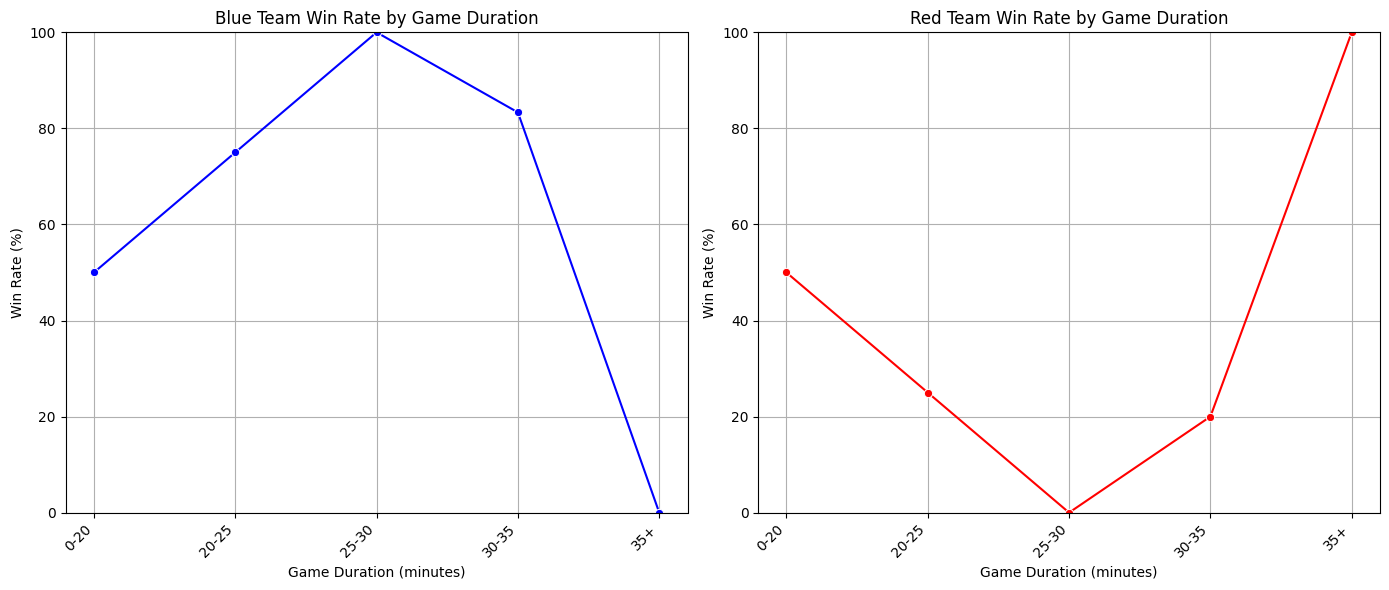

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(x='duration_bucket', y='blue_win_rate', data=win_rates_df, marker='o', color='blue')
plt.title('Blue Team Win Rate by Game Duration')
plt.xlabel('Game Duration (minutes)')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.xticks(rotation=45, ha='right')


plt.subplot(1, 2, 2)
sns.lineplot(x='duration_bucket', y='red_win_rate', data=win_rates_df, marker='o', color='red')
plt.title('Red Team Win Rate by Game Duration')
plt.xlabel('Game Duration (minutes)')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


/tmp/ipykernel_5988/1971001971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="team", y="gold_earned", palette={'blue': 'blue', 'red': 'red'})


<Axes: xlabel='team', ylabel='gold_earned'>

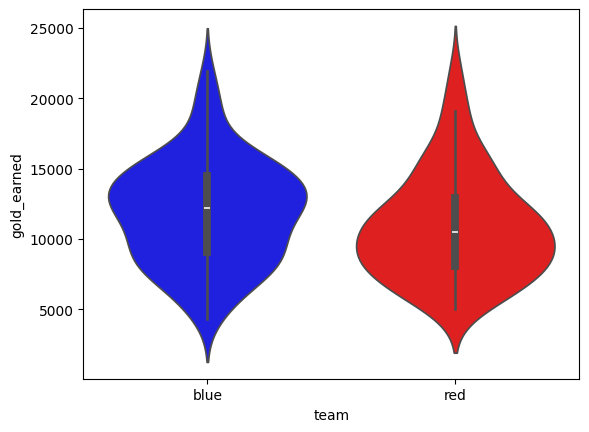

In [6]:
# Box/Violin Plot
df['gold_earned'] = pd.to_numeric(df['gold_earned'], errors='coerce')
df['team'] = df['team'].str.strip() # Ensure no leading/trailing spaces in team names
# sns.boxplot(data=df, x="team", y="gold_earned", palette={'blue': 'blue', 'red': 'red'})
sns.violinplot(data=df, x="team", y="gold_earned", palette={'blue': 'blue', 'red': 'red'})

In [ ]:
# Filters the data frame to only include data for champions that appear at least 3 times in the data set.
champion_counts = df['champion'].value_counts()
champions_to_keep = champion_counts[champion_counts >= 3].index
df_filtered_by_champion_count = df[df['champion'].isin(champions_to_keep)]

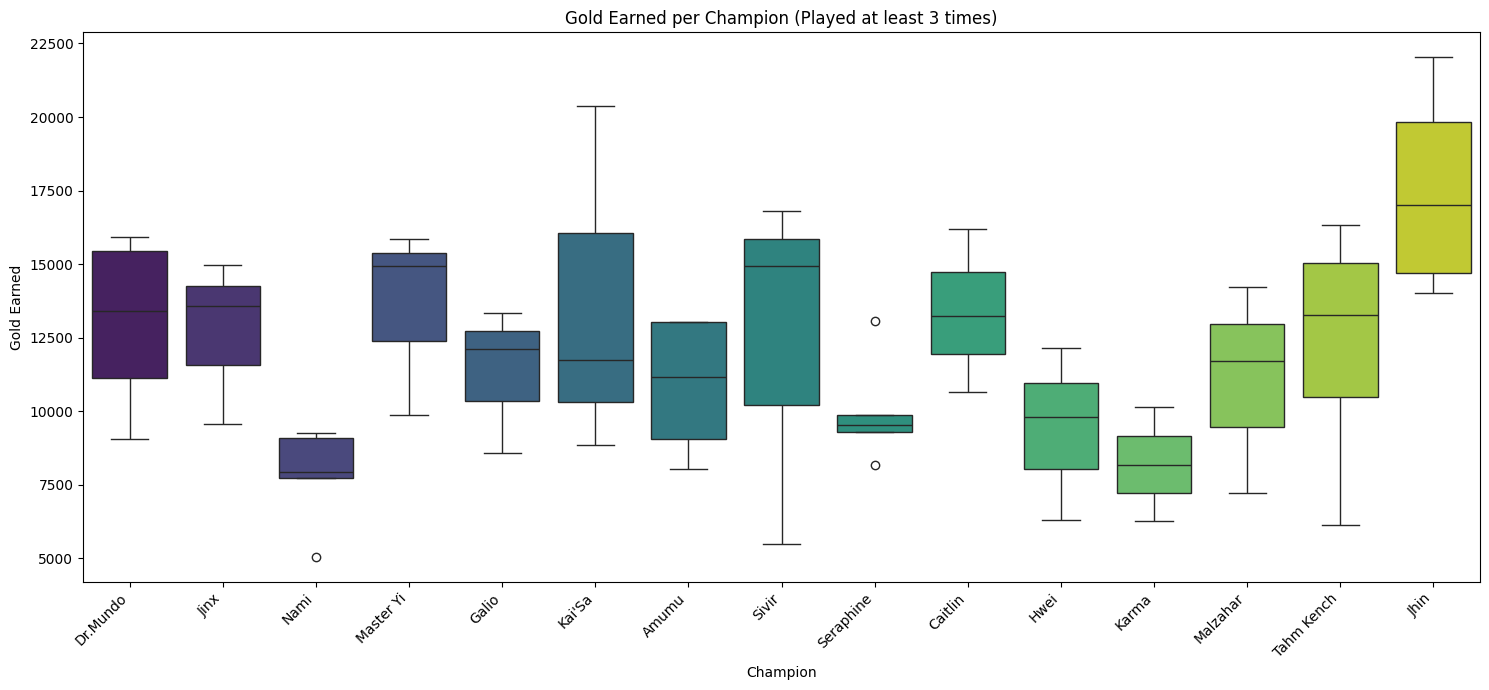

In [ ]:
df['gold_earned'] = pd.to_numeric(df['gold_earned'], errors='coerce')
champion_counts = df['champion'].value_counts()
champions_to_keep = champion_counts[champion_counts >= 3].index
df_filtered_by_champion_count = df[df['champion'].isin(champions_to_keep)]

import matplotlib.ticker as ticker

plt.figure(figsize=(15, 7))
sns.boxplot(data=df_filtered_by_champion_count, x="champion", y="gold_earned", hue="champion", palette='viridis', legend=False)
plt.title('Gold Earned per Champion (Played at least 3 times)')
plt.xlabel('Champion')
plt.ylabel('Gold Earned')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
plt.style.use('ggplot')
px.parallel_categories(df_filtered_by_champion_count[['champion', 'role']])

### Win Rate by Role (This diagram ended up not being used.)

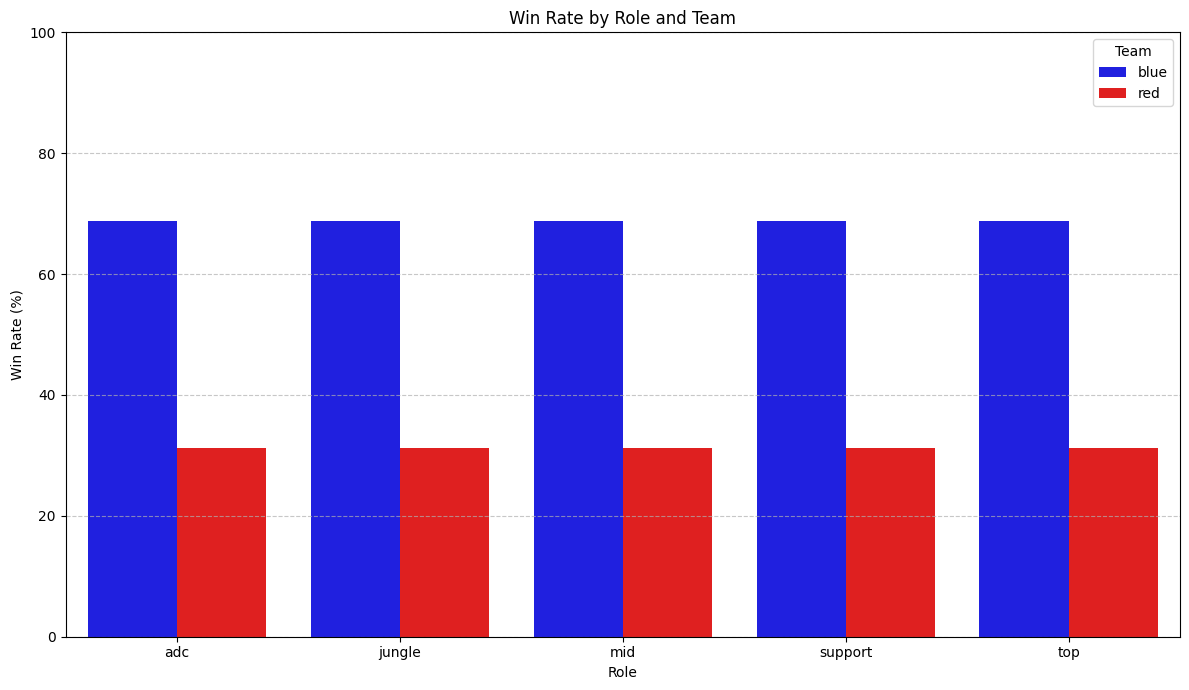

In [ ]:
df['team'] = df['team'].str.strip()
team_role_total_games = df.groupby(['team', 'role']).size().reset_index(name='total_games')
team_role_wins = df[df['win_loss'] == 'win'].groupby(['team', 'role']).size().reset_index(name='wins')

team_role_win_rates = pd.merge(team_role_total_games, team_role_wins, on=['team', 'role'], how='left').fillna(0)
team_role_win_rates['win_rate'] = (team_role_win_rates['wins'] / team_role_win_rates['total_games']) * 100

plt.figure(figsize=(12, 7))
sns.barplot(x='role', y='win_rate', hue='team', data=team_role_win_rates, palette={'blue': 'blue', 'red': 'red'})
plt.title('Win Rate by Role and Team')
plt.xlabel('Role')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Team')
plt.tight_layout()
plt.show()

/tmp/ipykernel_11696/1192725643.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_by_champion_count['kills'] = pd.to_numeric(df_filtered_by_champion_count['kills'], errors='coerce') # Making sure kills is numeric


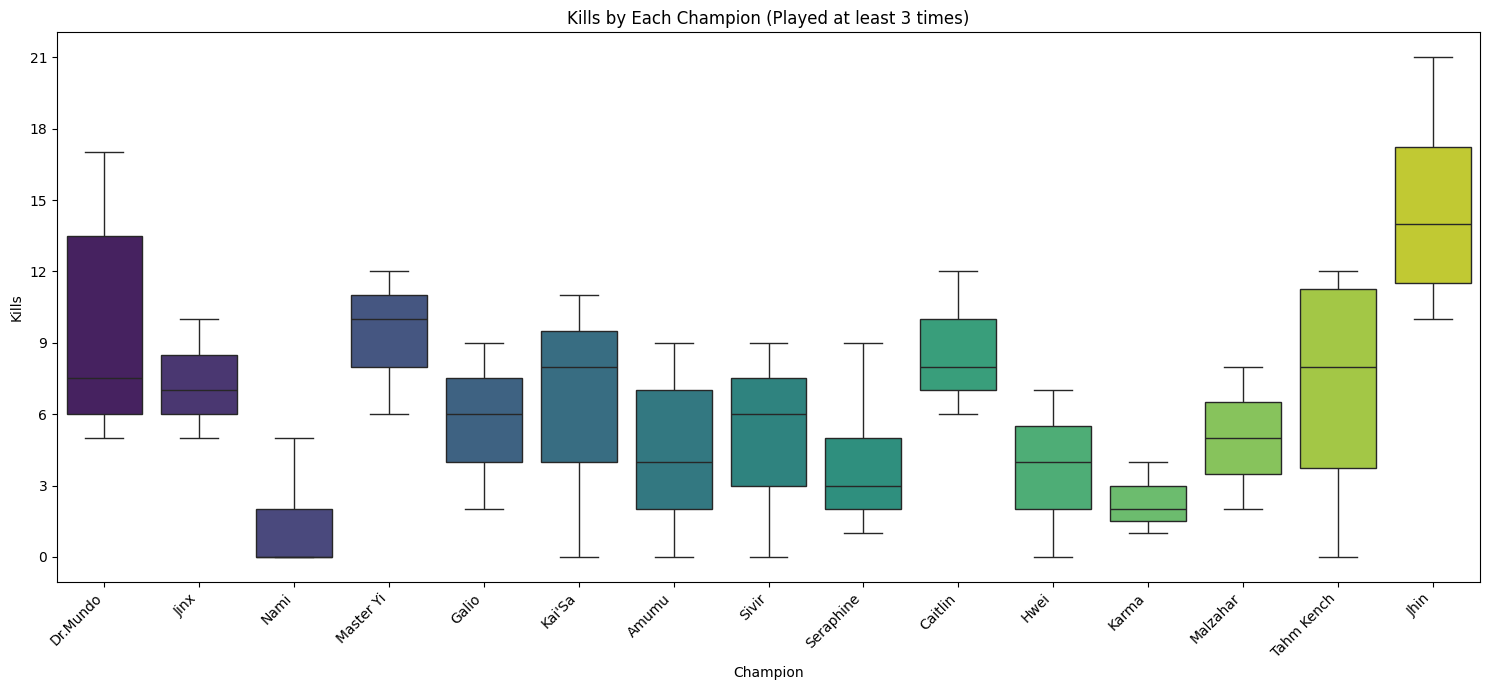

In [ ]:
# Boxplot for kills
df_filtered_by_champion_count['kills'] = pd.to_numeric(df_filtered_by_champion_count['kills'], errors='coerce')

plt.figure(figsize=(15, 7))
sns.boxplot(data=df_filtered_by_champion_count, x="champion", y="kills", hue="champion", palette='viridis', legend=False)
plt.title('Kills by Each Champion (Played at least 3 times)')
plt.xlabel('Champion')
plt.ylabel('Kills')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
plt.tight_layout()
plt.show()

/tmp/ipykernel_11696/2042185861.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_by_champion_count['deaths'] = pd.to_numeric(df_filtered_by_champion_count['deaths'], errors='coerce') # Making sure kills is numeric


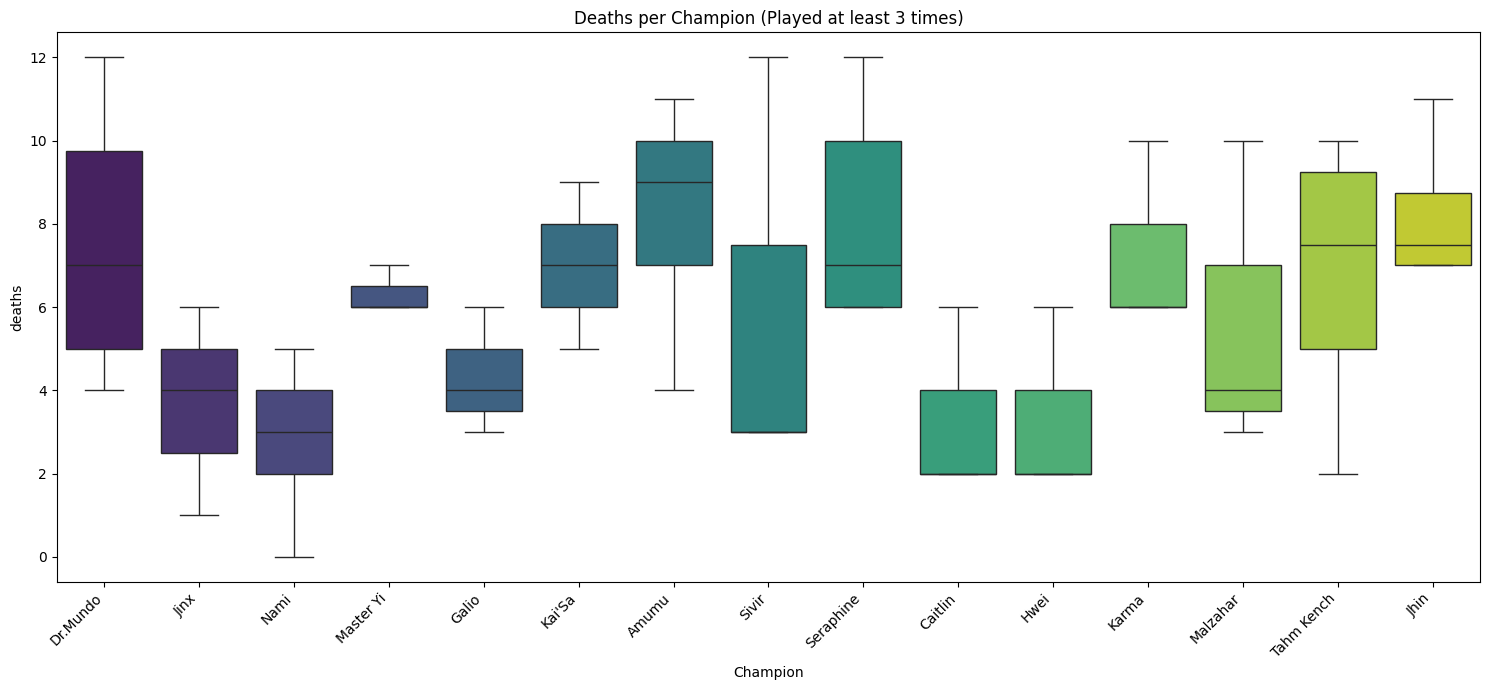

In [ ]:
# Boxplot for deaths
df_filtered_by_champion_count['deaths'] = pd.to_numeric(df_filtered_by_champion_count['deaths'], errors='coerce')

plt.figure(figsize=(15, 7))
sns.boxplot(data=df_filtered_by_champion_count, x="champion", y="deaths", hue="champion", palette='viridis', legend=False)
plt.title('Deaths per Champion (Played at least 3 times)')
plt.xlabel('Champion')
plt.ylabel('deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure plots display correctly
plt.rcParams["figure.figsize"] = (8, 6)

def create_heatmap():
    try:
        # Example: Create a sample DataFrame
        np.random.seed(42)  # For reproducibility
        data = np.random.randint(1, 100, size=(6, 6))
        df = pd.DataFrame(
            data,
            index=["A", "B", "C", "D", "E", "F"],
            columns=["Col1", "Col2", "Col3", "Col4", "Col5", "Col6"]
        )

        # Create the heatmap
        sns.heatmap(
            df,
            annot=True,        # Show values in cells
            fmt="d",           # Integer format
            cmap="YlGnBu",     # Color map
            linewidths=0.5,    # Lines between cells
            cbar_kws={"label": "Value"}  # Color bar label
        )

        # Add title
        plt.title("Sample Heatmap", fontsize=16)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error creating heatmap: {e}")

if __name__ == "__main__":
    create_heatmap()
